In [ ]:
!pip install --upgrade --force-reinstall numpy pandas gensim nltk gdown scikit-learn matplotlib seaborn wordcloud Sastrawi catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 463.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 850.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gdown
from collections import Counter

from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

import warnings
from IPython.display import clear_output
warnings.filterwarnings('ignore')

clear_output()

In [ ]:
# Download data
url = "https://drive.google.com/file/d/15IMmfkcK06g9Gb5QxtrU1IUzrq4qSrsP/view?usp=sharing"
downloaded_file_path = gdown.download(id=url.split('/')[-2]  , quiet=False)
clear_output()

# Read and filter data
df = pd.read_csv(downloaded_file_path)
df = df[df['to_drop'].isnull()]
df = df[['is_negative',	'is_netral', 'is_positive', 'to_drop', 'full_text']]

df.head()

,is_negative,is_netral,is_positive,to_drop,full_text
0,NaN,1.0,NaN,NaN,setelah nyobain deepseek versi free di webnya ...
2,NaN,1.0,NaN,NaN,@Yukikaze_D_2 @BudiBukanIntel DeepSeek R1 reas...
3,NaN,NaN,1.0,NaN,Bes pulak borak dengan deepseek ni. Tere BM dia.
4,NaN,1.0,NaN,NaN,1.Setelah Washington melarang Nvidia mengekspo...
5,NaN,1.0,NaN,NaN,Mau nyoba Deepseek


In [ ]:
df = df.rename(columns={'to_drop': 'label'})

df['label'] = np.where(df['is_netral'] == 1, 'netral',
              np.where(df['is_negative'] == 1, 'negative',
              np.where(df['is_positive'] == 1, 'positive', '')))

df = df[df['label'] != '']
df = df[['label', 'full_text']]
df.head()

,label,full_text
0,netral,setelah nyobain deepseek versi free di webnya ...
2,netral,@Yukikaze_D_2 @BudiBukanIntel DeepSeek R1 reas...
3,positive,Bes pulak borak dengan deepseek ni. Tere BM dia.
4,netral,1.Setelah Washington melarang Nvidia mengekspo...
5,netral,Mau nyoba Deepseek


In [ ]:
# Inisialisasi Stopwords
stopword_bahasa = pd.read_csv('https://raw.githubusercontent.com/rizky-22017-mhs-unesa-ac-id/Sentiment-Analysis-of-KIP-Recipients-based-on-Tweets-from-X/main/Dataset/TextNormalization/stopwordbahasa.csv', encoding='latin-1')
stopword_bahasa = stopword_bahasa.rename(columns={0: 'stop'})
remove_words = ['deepseek', 'chatgpt']

kamus_alay = pd.read_csv('https://raw.githubusercontent.com/rizky-22017-mhs-unesa-ac-id/Sentiment-Analysis-of-KIP-Recipients-based-on-Tweets-from-X/main/Dataset/TextNormalization/kamus_alay.csv', header=None, encoding='latin-1')
kamus_alay = kamus_alay.rename(columns={0: 'original',
                                     1: 'replacement'})
kamus_alay_map = dict(zip(kamus_alay['original'], kamus_alay['replacement']))

kamus_singkatan = pd.read_csv('https://raw.githubusercontent.com/rizky-22017-mhs-unesa-ac-id/Sentiment-Analysis-of-KIP-Recipients-based-on-Tweets-from-X/main/Dataset/TextNormalization/kamus_singkatan.csv', sep=';', encoding='latin-1')
kamus_singkatan.columns = ['Column1', 'Column2']
kamus_singkatan = kamus_singkatan.rename(columns={'Column1': 'original', 'Column2': 'replacement'})
kamus_singkatan_map = dict(zip(kamus_singkatan['original'], kamus_singkatan['replacement']))

# Inisialisasi Stemmer berbahasa Indonesia
def stemming(text_cleaning):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    do = []
    for w in text_cleaning:
        dt = stemmer.stem(w)
        do.append(dt)
    return ' '.join(do)

def remove_stopword(text):
    text = ' '.join([ ' ' if word in stopword_bahasa.ada.values else word for word in text.split(' ')])
    text = re.sub('  +', ' ', text) # Remove extra spaces
    text = text.strip()
    return text

# Text Cleaning dengan Stemming menggunakan Sastrawi
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub('\n', ' ', text) # Remove every newline character
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text) # Remove every username
    text = re.sub('user', ' ', text) # Remove every occurrence of the word 'user'
    text = re.sub('rt', ' ', text) # Remove every retweet symbol
    text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', ' ', text) # Remove every URL
    text = re.sub('https?://t\.me/[^\s]+', ' ', text) # Remove every Telegram link
    text = re.sub('pic.twitter.com/[^\s]+', ' ', text) # Remove every Twitter image link
    text = re.sub ('[^0-9a-zA-Z]+', ' ', text) # Remove every non-alphanumeric character
    text = re.sub('  +', ' ', text) # Remove extra spaces
    words = text.split()
    for word in remove_words:
        text = re.sub(word, '', text)  # remove word
    return text
    text = " ".join([kamus_alay_map[word] if word in kamus_alay_map else word for word in text.split(' ')])
    return text
    text = " ".join([kamus_singkatan_map[word] if word in kamus_singkatan_map else word for word in text.split(' ')])
    return text
    text = remove_stopword(text)
    text = stemming(text)


def clean_df(data: pd.DataFrame) -> pd.DataFrame:
    data['cleaned'] = data['full_text'].apply(clean_text)
    return data

df = clean_df(df)
df.head()

,label,full_text,cleaned
0,netral,setelah nyobain deepseek versi free di webnya ...,setelah nyobain versi free di webnya langsung...
2,netral,@Yukikaze_D_2 @BudiBukanIntel DeepSeek R1 reas...,r1 reasoning model jalankan secara lokal pal...
3,positive,Bes pulak borak dengan deepseek ni. Tere BM dia.,bes pulak borak dengan ni tere bm dia
4,netral,1.Setelah Washington melarang Nvidia mengekspo...,1 setelah washington melarang nvidia mengekspo...
5,netral,Mau nyoba Deepseek,mau nyoba


In [ ]:
# TF-IDF Initialization
tfidf = TfidfVectorizer(max_features=2100)
tfidf.fit(df['cleaned'])

# Get Features as X and Label as y
X_tfidf = tfidf.transform(df['cleaned']).toarray()
y = df['label']

In [ ]:
# Split data for TF-IDF
X_tfidf_train, X_tfidf_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
# Handle imbalance for TF-IDF
smote_tfidf = SMOTE(random_state=42)
X_tfidf_train, y_train_smote = smote_tfidf.fit_resample(X_tfidf_train, y_train)

In [ ]:
# Training TF-IDF models
## Support Vector Machine
sv1 = LinearSVC(random_state=42, C=0.5)
sv1.fit(X_tfidf_train, y_train_smote)

## Random Forest
rf1 = RandomForestClassifier(n_estimators=400, criterion='entropy', random_state=42, max_depth=25)
rf1.fit(X_tfidf_train, y_train_smote)

## Catboost
cb1 = CatBoostClassifier(learning_rate=0.05, l2_leaf_reg=5, verbose=0, random_state=42)
cb1.fit(X_tfidf_train, y_train_smote)

## Naive Bayes
nb1 = MultinomialNB()
nb1.fit(X_tfidf_train, y_train_smote)
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tfidf_train, y_train_smote)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
gb.fit(X_tfidf_train, y_train_smote)

print('TF-IDF Models Trained Successfully!')

TF-IDF Models Trained Successfully!


In [ ]:
def evaluate_model(model, X_data, y_data):
    y_pred = model.predict(X_data)
    accuracy = accuracy_score(y_data, y_pred)
    bal_acc = balanced_accuracy_score(y_data, y_pred)
    cm = confusion_matrix(y_data, y_pred)
    macro_f1 = f1_score(y_data, y_pred, average='macro')
    return accuracy, bal_acc, cm, y_pred, macro_f1

# Calculate metrics for TF-IDF models
acc_sv, bal_acc_sv, cm_sv, y_pred_sv, macro_f1_sv = evaluate_model(sv1, X_tfidf_test, y_test)
acc_rf, bal_acc_rf, cm_rf, y_pred_rf, macro_f1_rf = evaluate_model(rf1, X_tfidf_test, y_test)
acc_cb, bal_acc_cb, cm_cb, y_pred_cb, macro_f1_cb = evaluate_model(cb1, X_tfidf_test, y_test)
acc_nb, bal_acc_nb, cm_nb, y_pred_nb, macro_f1_nb = evaluate_model(nb1, X_tfidf_test, y_test)
acc_lr, bal_acc_lr, cm_lr, y_pred_lr, macro_f1_lr = evaluate_model(lr, X_tfidf_test, y_test)
acc_gb, bal_acc_gb, cm_gb, y_pred_gb, macro_f1_gb = evaluate_model(gb, X_tfidf_test, y_test)


# Compare metrics
model_names = ["SVM", "Random Forest", "CatBoost", "Naive Bayes", "Logistic Regression", "Gradient Boosting"]

metrics_tfidf = pd.DataFrame({
    "Model": model_names,
    "Accuracy": [acc_sv, acc_rf, acc_cb, acc_nb, acc_lr, acc_gb],
    "Balanced Accuracy": [bal_acc_sv, bal_acc_rf, bal_acc_cb, bal_acc_nb, bal_acc_lr, bal_acc_gb],
    "Macro F1 Score": [macro_f1_sv, macro_f1_rf, macro_f1_cb, macro_f1_nb, macro_f1_lr, macro_f1_gb]
})

metrics_tfidf

,Model,Accuracy,Balanced Accuracy,Macro F1 Score
0,SVM,0.640,0.625456,0.626367
1,Random Forest,0.570,0.533905,0.547123
2,CatBoost,0.575,0.530028,0.544039
3,Naive Bayes,0.610,0.605762,0.596944
4,Logistic Regression,0.620,0.597357,0.600075
5,Gradient Boosting,0.575,0.536194,0.547615


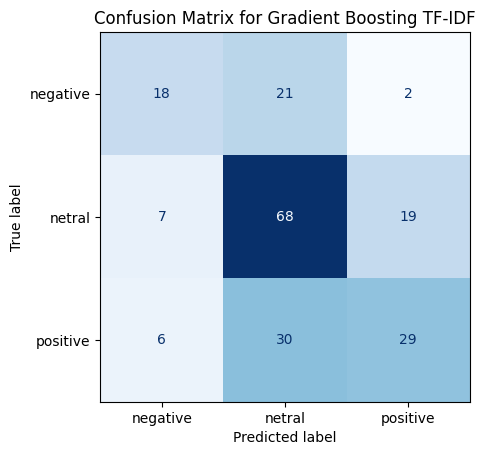

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=sv1.classes_)
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title('Confusion Matrix for Gradient Boosting TF-IDF')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(f'          Classification Report for Gradient Boosting')
print(classification_report(y_test, y_pred_gb))

          Classification Report for Gradient Boosting
              precision    recall  f1-score   support

    negative       0.58      0.44      0.50        41
      netral       0.57      0.72      0.64        94
    positive       0.58      0.45      0.50        65

    accuracy                           0.57       200
   macro avg       0.58      0.54      0.55       200
weighted avg       0.58      0.57      0.57       200

